#                                 **OLA**

**About OLA**

**Ola** is one of India's leading ride-hailing platforms, offering a variety of transportation services, including rides for passengers and logistics solutions. The company operates in multiple cities across India and several international markets, competing with global players like Uber.

**Problem Statement**

**Ola** faces a high driver churn rate, leading to increased recruitment costs and reduced company morale. The goal is to predict which drivers are at risk of leaving the platform to develop targeted retention strategies and reduce churn.

# **Exploratory Data Analysis**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv
To: /content/ola_driver_scaler.csv
100% 1.13M/1.13M [00:01<00:00, 862kB/s]


In [ ]:
df = pd.read_csv('ola_driver_scaler.csv')

In [ ]:
df.shape # Number of rows and columns

(19104, 14)

In [ ]:
df.info() # Columns names and its datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [ ]:
df.drop( ['Unnamed: 0'], axis=1, inplace=True) # dropping the least important columns

In [ ]:
#Converting the datatypes
df['Gender'] = df['Gender'].astype('category')
df['City'] = df['City'].astype('category')
df['Education_Level'] = df['Education_Level'].astype('category')
df['Grade'] = df['Grade'].astype('category')

In [ ]:
df['Gender'] = df['Gender'].apply(lambda x: 'Female' if x == 1 else 'Male')

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,11074
Female,7978


In [ ]:
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'], errors='coerce')
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], errors='coerce')

<ipython-input-10-a5d93f183aa6>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'], errors='coerce')
<ipython-input-10-a5d93f183aa6>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], errors='coerce')


In [ ]:
df.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,Male,C23,2,57387,2018-12-24,NaT,1,1,2381060,2
1,02/01/19,1,28.0,Male,C23,2,57387,2018-12-24,NaT,1,1,-665480,2
2,03/01/19,1,28.0,Male,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2
3,11/01/20,2,31.0,Male,C7,2,67016,2020-11-06,NaT,2,2,0,1
4,12/01/20,2,31.0,Male,C7,2,67016,2020-11-06,NaT,2,2,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                19104 non-null  object        
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  category      
 4   City                  19104 non-null  category      
 5   Education_Level       19104 non-null  category      
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   LastWorkingDate       1616 non-null   datetime64[ns]
 9   Joining Designation   19104 non-null  int64         
 10  Grade                 19104 non-null  category      
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
dtypes: category(4), 

In [ ]:
df.describe() # Statistical summary of the data

,Driver_ID,Age,Income,Dateofjoining,LastWorkingDate,Joining Designation,Total Business Value,Quarterly Rating
count,19104.000000,19043.000000,19104.000000,19104,1616,19104.000000,1.910400e+04,19104.000000
mean,1415.591133,34.668435,65652.025126,2018-04-28 20:52:54.874371840,2019-12-21 20:59:06.534653696,1.690536,5.716621e+05,2.008899
min,1.000000,21.000000,10747.000000,2013-04-01 00:00:00,2018-12-31 00:00:00,1.000000,-6.000000e+06,1.000000
25%,710.000000,30.000000,42383.000000,2016-11-29 12:00:00,2019-06-06 00:00:00,1.000000,0.000000e+00,1.000000
50%,1417.000000,34.000000,60087.000000,2018-09-12 00:00:00,2019-12-20 12:00:00,1.000000,2.500000e+05,2.000000
75%,2137.000000,39.000000,83969.000000,2019-11-05 00:00:00,2020-07-03 00:00:00,2.000000,6.997000e+05,3.000000
max,2788.000000,58.000000,188418.000000,2020-12-28 00:00:00,2020-12-28 00:00:00,5.000000,3.374772e+07,4.000000
std,810.705321,6.257912,30914.515344,NaN,NaN,0.836984,1.128312e+06,1.009832


# **Univariate Analysis**

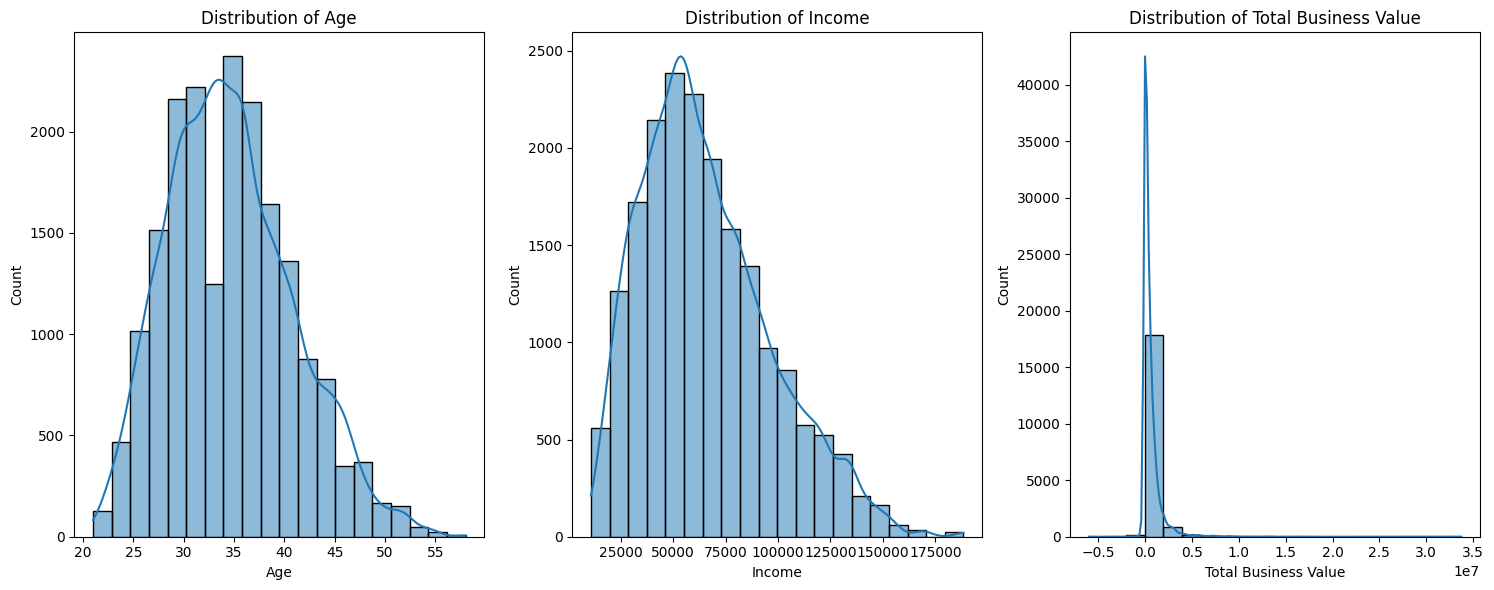

In [ ]:
# Continuous variables: Age, Income, Total Business Value, Quarterly Rating
continuous_features = ['Age', 'Income', 'Total Business Value']

plt.figure(figsize=(15, 6))
for i, feature in enumerate(continuous_features, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df[feature], bins=20, kde=True)
  plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

**Insights :**

**Age :** The distribution of age appears to be approximately normal, with a peak around the mid-30s. This suggests that a significant portion of the customers are in this age group.

**Income :** The distribution of income is right-skewed, there are more customers with lower incomes and fewer with higher incomes.

**Total Business Value :** The distribution of total business value is also right-skewed, similar to income. This suggests that a small number of customers contribute a significant portion of the total business value.

# **Outliers**

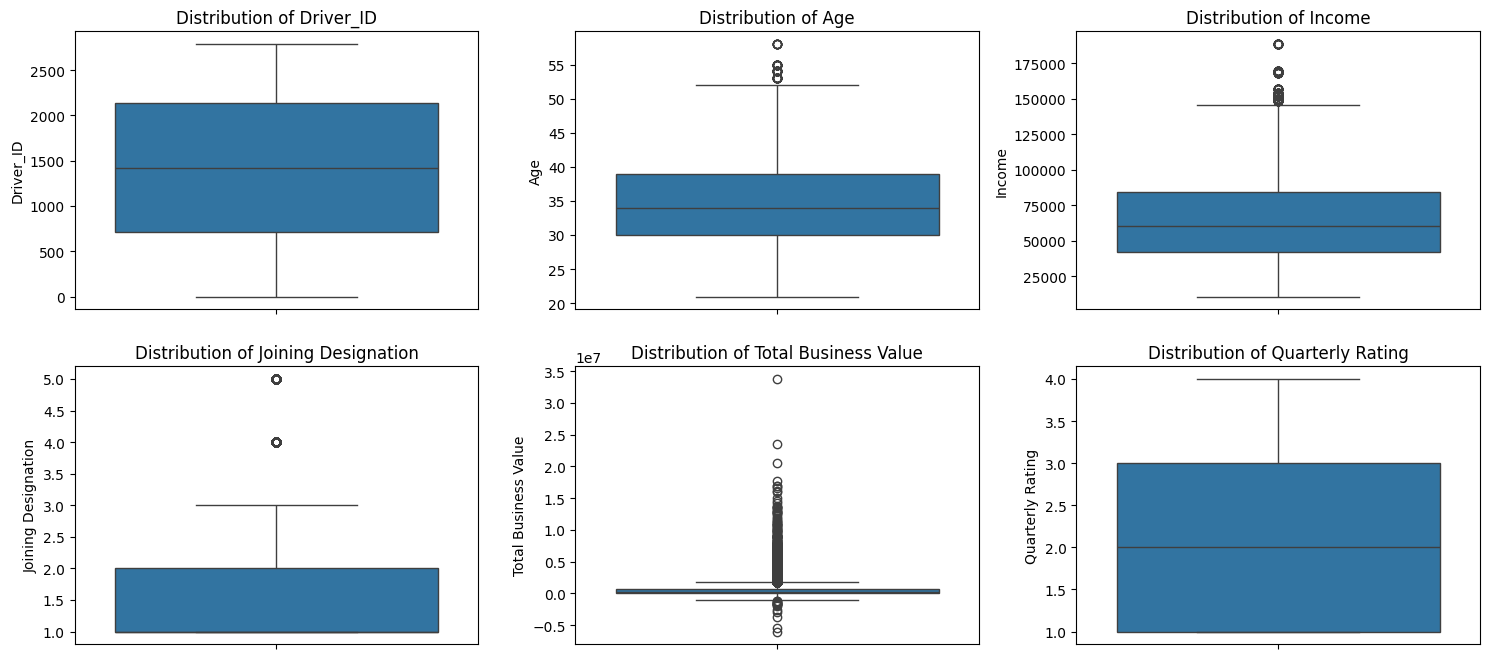

In [ ]:
continuous_features_2 = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(15,10))
for i, feature in enumerate(continuous_features_2, 1):
  plt.subplot(3, 3, i)
  sns.boxplot(df[feature])
  plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

**Insights :**

There are significant number of outliers in Total Business Value both on upper bound and lower bound.There are few outliers on the upper bound in Age and Income.

In [ ]:
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [ ]:
def clip_outliers(data):# Function to clip the data to the bounds
    lower_bound, upper_bound = detect_outliers_iqr(data)
    return np.clip(data, lower_bound, upper_bound)

In [ ]:
# Clipping the specified columns
df['Age'] = clip_outliers(df['Age'])
df['Income'] = clip_outliers(df['Income'])
df['Total Business Value'] = clip_outliers(df['Total Business Value'])
df['Joining Designation'] = clip_outliers(df['Joining Designation'])

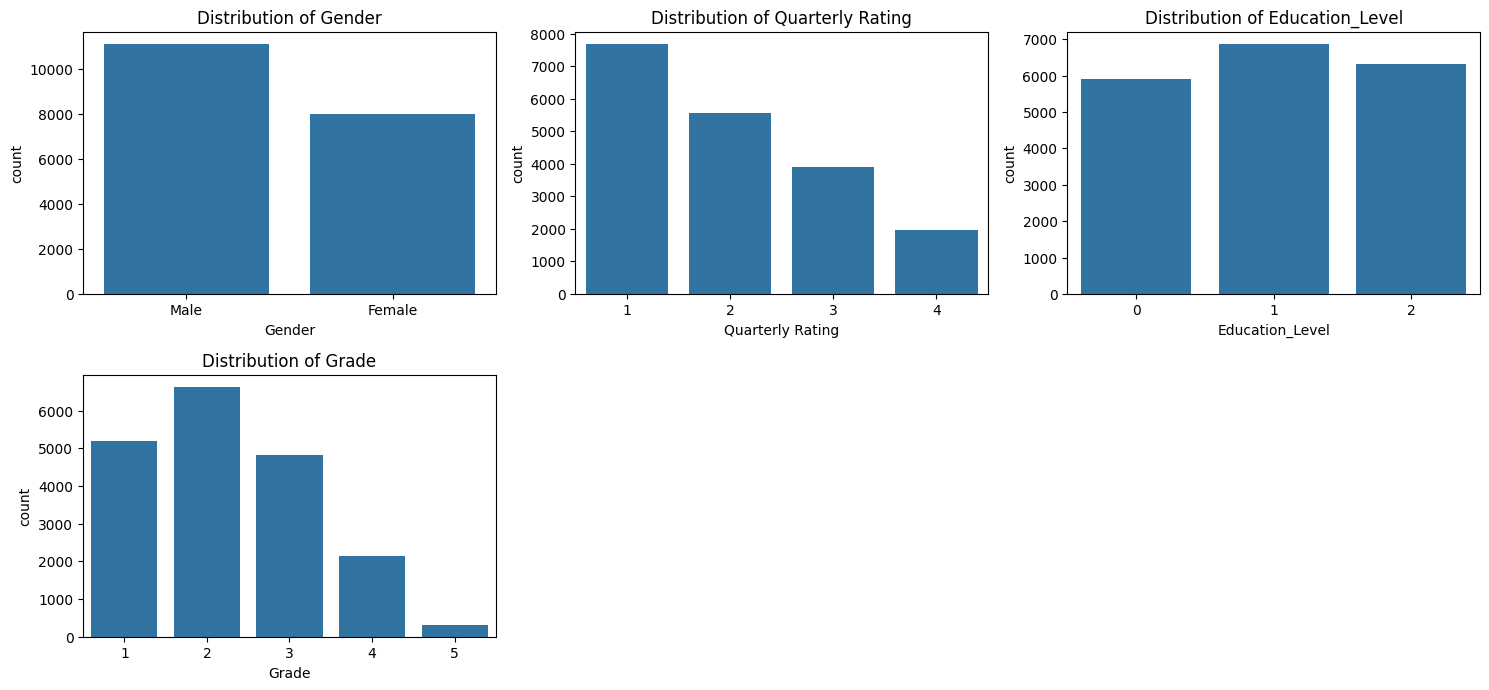

In [ ]:
categorical_features = ['Gender', 'Quarterly Rating' ,'Education_Level', 'Grade']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features, 1):
  plt.subplot(3, 3, i)
  sns.countplot(x=df[feature])
  plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# **Insights and Recommendations :**

**Distribution of Gender :**


1.  The dataset appears to be dominated by male drivers.
2.  There is a significant difference in the number of male and female drivers.

**Distribution of Quarterly Rating :**


1.   Most drivers have a quarterly rating of 1 or 2.The number of drivers with higher ratings (3, 4, and 5) decreases significantly.
2.   This suggests that a majority of drivers are performing at a basic level.

**Distribution of Education Level :**


1.   Most drivers have an education level of 1 (12+).
2.   A smaller proportion of drivers have higher education levels (2 for graduate).

**Distribution of Grade :**


1.   Most drivers have a grade of 1 or 2.The number of drivers with higher grades (3, 4, and 5) decreases significantly.
2.   This is similar to the distribution of quarterly ratings, suggesting a possible correlation between the two.

# **Recommendations :**

**Gender Imbalance :** The significant gender imbalance might indicate potential biases or discrimination in the hiring or retention process. It's important to investigate this further to ensure fairness and equal opportunities.

**Performance Distribution :** The concentration of drivers in lower rating categories suggests a need for improved driver training and performance management.

**Correlation between Ratings and Grades:** The similar distribution of quarterly ratings and grades suggests a strong correlation between these two metrics. This could be used to identify potential performance trends and areas for improvement.

# **Bivariate Analysis**

<ipython-input-20-c50e3801fd02>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_business_value = df.groupby('Gender')['Total Business Value'].sum().reset_index()
<ipython-input-20-c50e3801fd02>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_income = df.groupby('Gender')['Income'].sum().reset_index()
<ipython-input-20-c50e3801fd02>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_cities = df.groupby('

Text(0.5, 1.0, 'Total Income by Gender')

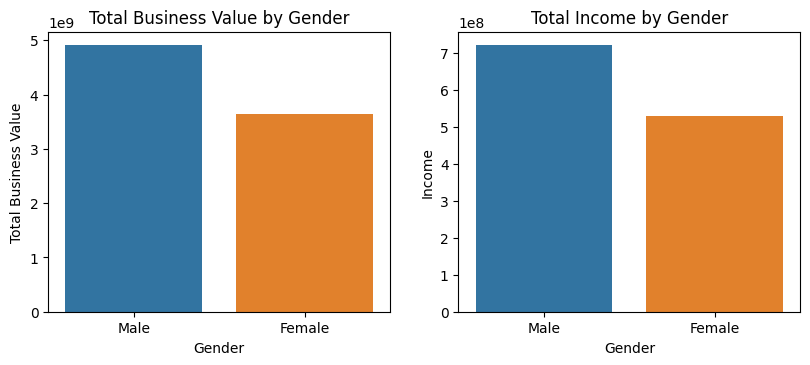

In [ ]:
gender_business_value = df.groupby('Gender')['Total Business Value'].sum().reset_index()
gender_income = df.groupby('Gender')['Income'].sum().reset_index()
top_cities = df.groupby('City')['Total Business Value'].sum().reset_index()
top_10 = top_cities.sort_values(by='Total Business Value', ascending=False).head(10)

plt.figure(figsize=(15, 8))
plt.subplot(2,3,1)
sns.barplot(x='Gender', y='Total Business Value', data = gender_business_value,hue = 'Gender')
plt.title('Total Business Value by Gender')


plt.subplot(2,3,2)
sns.barplot(x='Gender', y='Income', data = gender_income,hue = 'Gender')
plt.title('Total Income by Gender')

# plt.subplot(2,3,3)
# sns.barplot(x='City', y = 'Total Business Value',data = top_10)
# plt.title('Top 10 Cities')
# plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
# plt.show()

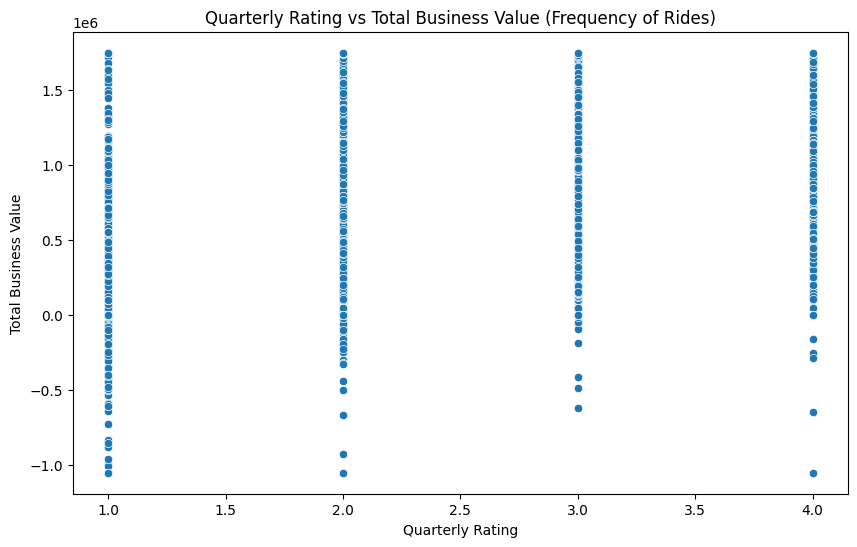

Correlation coefficient between Quarterly Rating and Total Business Value: 0.6392926288503664


In [ ]:
Quarterly_Rating_business_value = df.groupby('Quarterly Rating')['Total Business Value'].sum().reset_index()

# Scatter plot of Quarterly Rating vs. Total Business Value (Frequency of Rides)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quarterly Rating', y='Total Business Value', data=df)
plt.title('Quarterly Rating vs Total Business Value (Frequency of Rides)')
plt.xlabel('Quarterly Rating')
plt.ylabel('Total Business Value')
plt.show()

# Correlation coefficient between Quarterly Rating and Total Business Value
correlation = df['Quarterly Rating'].corr(df['Total Business Value'])
print(f'Correlation coefficient between Quarterly Rating and Total Business Value: {correlation}')


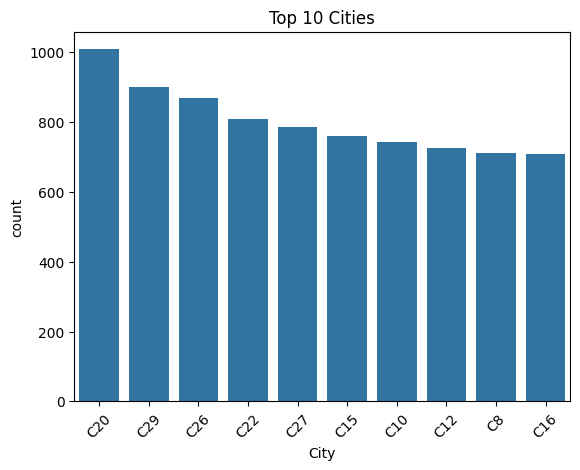

In [ ]:
top_cities = df['City'].value_counts().nlargest(10).index

# Plotting
sns.countplot(data=df[df['City'].isin(top_cities)], x='City', order=top_cities)
plt.title('Top 10 Cities')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [ ]:
corr = df.corr(numeric_only= True)

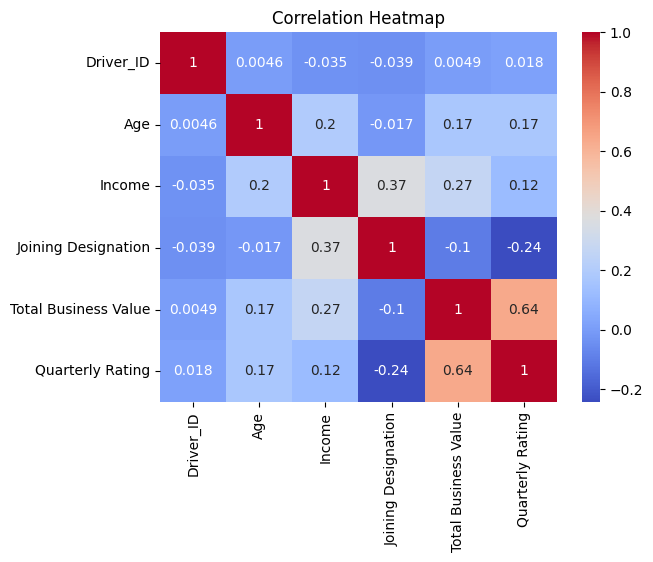

In [ ]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Strong Correlation between Performance and Business Value :** Drivers with higher quarterly ratings tend to generate higher total business value.

**Impact of Income and Age :** Income and age have a positive correlation with business value, other factors like performance and experience also play a significant role.

**Joining Designation and Performance :** Certain joining designations might be associated with lower performance, indicating potential areas for improvement in training and development.

In [ ]:
# Aggregating the data by Driver_ID
df_aggregated = df.groupby('Driver_ID').agg({
    'Age': 'first',  # Assuming Age remains constant for each driver
    'Gender': 'first',  # Assuming Gender remains constant for each driver
    'City': 'first',  # Assuming City remains constant for each driver
    'Education_Level': 'first',  # Assuming Education_Level remains constant
    'Dateofjoining': 'first',  # Assuming Dateofjoining remains constant
    'LastWorkingDate': 'first',  # Assuming LastWorkingDate remains constant
    'Income': 'mean',  # Average income over time
    'Total Business Value': 'sum',  # Sum of business value over time
    'Quarterly Rating': 'mean',  # Average quarterly rating
    'Grade': 'first',  # Assuming Grade remains constant
    'Joining Designation': 'first',  # Joining Designation remains constant
    'LastWorkingDate': 'max',  # Get the last working date
}).reset_index()


In [ ]:
df_aggregated['Tenure'] = (df_aggregated['LastWorkingDate'] - df_aggregated['Dateofjoining']).dt.days // 30

In [ ]:
def categorize_tenure(tenure):
    if pd.isna(tenure):
        return 'Active'
    elif tenure <= 6:
        return 'New'
    elif tenure <= 24:
        return 'Mid-term'
    else:
        return 'Long-term'

df_aggregated['Tenure Category'] = df_aggregated['Tenure'].apply(categorize_tenure)


In [ ]:
df_aggregated.drop('Tenure', axis=1, inplace=True)

In [ ]:
df_aggregated.head()

,Driver_ID,Age,Gender,City,Education_Level,Dateofjoining,LastWorkingDate,Income,Total Business Value,Quarterly Rating,Grade,Joining Designation,Tenure Category
0,1,28.0,Male,C23,2,2018-12-24,2019-03-11,57387.0,1083770,2.0,1,1.0,New
1,2,31.0,Male,C7,2,2020-11-06,NaT,67016.0,0,1.0,2,2.0,Active
2,4,43.0,Male,C13,2,2019-12-07,2020-04-27,65603.0,350000,1.0,2,2.0,New
3,5,29.0,Male,C9,0,2019-01-09,2019-03-07,46368.0,120360,1.0,1,1.0,New
4,6,31.0,Female,C11,1,2020-07-31,NaT,78728.0,1265000,1.6,3,3.0,Active


In [ ]:
missing_values = df_aggregated.isnull().sum() # Missing value check
print(missing_values[missing_values > 0])

LastWorkingDate    765
dtype: int64


In [ ]:
# Feature: Quarterly rating improvement (if rating increased)
df_aggregated['Quarterly_Rating_Increased'] = (df_aggregated['Quarterly Rating'].diff() > 0).astype(int)

# Feature: Monthly income increase (if income increased)
df_aggregated['Income_Increased'] = (df_aggregated['Income'].diff() > 0).astype(int)

# Target Variable: Attrition (1 if LastWorkingDate is not null, 0 otherwise)
df_aggregated['Target'] = df_aggregated['LastWorkingDate'].notnull().astype(int)

# Drop LastWorkingDate & Dateofjoining as it is no longer needed
df_aggregated.drop(columns = ['LastWorkingDate','Dateofjoining'], axis=1, inplace=True)

In [ ]:
from sklearn.impute import KNNImputer

# Select numerical columns for KNN imputation
numerical_cols = df_aggregated.select_dtypes(include=[np.number]).columns
df_numerical = df_aggregated[numerical_cols]

# Impute missing values using KNN imputation
imputer = KNNImputer(n_neighbors=5)
df_numerical_imputed = pd.DataFrame(imputer.fit_transform(df_numerical), columns=df_numerical.columns)

# Replace the original numerical columns with the imputed data
df_aggregated[numerical_cols] = df_numerical_imputed


In [ ]:
missing_values = df_aggregated.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


**Encoding**

In [ ]:
#One-Hot encoding for Gender & Tenure Category
df_aggregated = pd.get_dummies(df_aggregated, columns=['Gender','Tenure Category'], drop_first=True)

In [ ]:
#Target encoding for City
city_mapping = df_aggregated.groupby('City')['Target'].mean().to_dict()
df_aggregated['City_Encoded'] = df_aggregated['City'].map(city_mapping)
df_aggregated.drop('City', axis=1, inplace=True)

In [ ]:
# # Separate features and target
X = df_aggregated.drop(['Driver_ID','Target'], axis=1)
y = df_aggregated['Target']

**Class Imbalance Treatment**

In [ ]:
# Calculate the imbalance ratio
class_counts = y.value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]  # Assuming 0 is the majority class
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f}")


Class Imbalance Ratio: 0.47


In [ ]:
# Check the proportions of each class
class_proportions = y.value_counts(normalize=True)
print(class_proportions)


Target
1.0    0.678706
0.0    0.321294
Name: proportion, dtype: float64


In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE for oversampling the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


**Standardization**

In [ ]:
# Step 1: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Initialize the scaler
scaler = StandardScaler()

# Step 3: Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Step 4: Transform the test data using the same scaler (no fitting)
X_test_scaled = scaler.transform(X_test)

**Bagging : Random Forest**

Random Forest Classifier:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       150
         1.0       1.00      1.00      1.00       327

    accuracy                           1.00       477
   macro avg       1.00      1.00      1.00       477
weighted avg       1.00      1.00      1.00       477



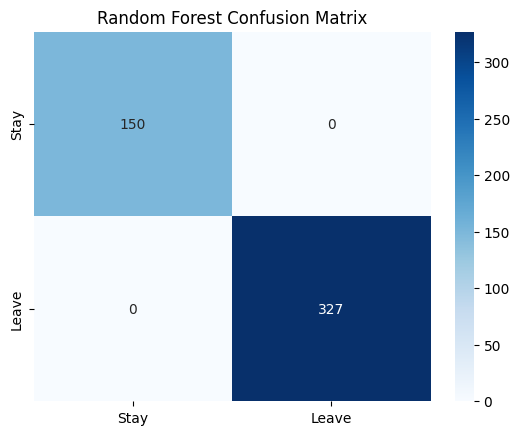

In [ ]:
# Bagging Algorithm - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

# Model Evaluation
print("Random Forest Classifier:")
print(classification_report(y_test, y_pred_rf))
# conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
# print("Confusion Matrix:\n", conf_matrix_rf)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
plt.title('Random Forest Confusion Matrix')
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       0.31      1.00      0.48       150
         1.0       0.00      0.00      0.00       327

    accuracy                           0.31       477
   macro avg       0.16      0.50      0.24       477
weighted avg       0.10      0.31      0.15       477

ROC AUC Score: 0.5


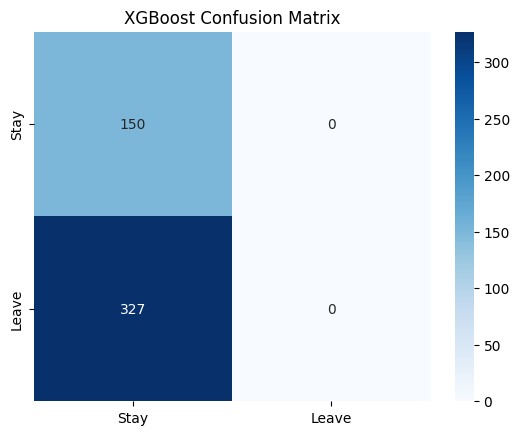

In [ ]:
import xgboost as xgb

# Build and train XGBoost model
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Predict on training data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred_xgb))
print(f'ROC AUC Score: {roc_auc_score(y_test, y_pred_xgb)}')

# Confusion Matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
plt.title('XGBoost Confusion Matrix')
plt.show()


## **Insights :**

**High Accuracy :** The model achieved a perfect accuracy of 1.00, indicating it correctly predicted all instances.

**Precision and Recall :** Both precision and recall are 1.00 for both classes, meaning the model correctly identified all positive and negative instances.

**Balanced Performance :** The model performed equally well on both classes ("Stay" and "Leave"), suggesting it's not biased towards any particular class.

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


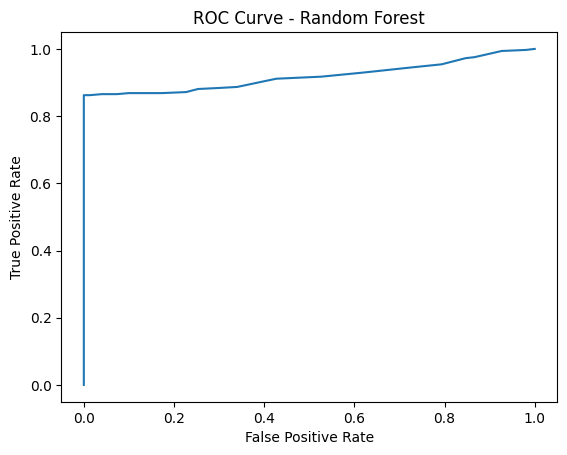

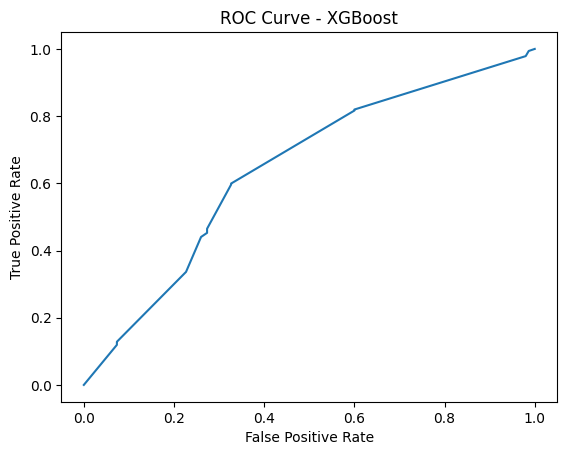

In [ ]:
from sklearn.metrics import roc_curve

# ROC Curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

# ROC Curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')
plt.title('ROC Curve - XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()


**Interpreting the ROC Curves :**

**1. Random Forest :** The curve is closer to the top-left corner, indicating a good model performance.
A higher area under the curve (AUC) suggests better classification accuracy.

**2. XGBoost :** The curve is also reasonably close to the top-left corner, indicating good performance.
However, it's slightly below the Random Forest curve, suggesting that the Random Forest model might be marginally better in this case.



*   Both models seem to perform well, but Random Forest appears to have a slight edge based on the ROC curve.

